# Basic comparsion of naive and fast convolution

In [1]:
import numpy as np
import sympy as sy
from PIL import Image
from scipy import signal
from scipy import datasets
from matplotlib import pyplot as plt

In [2]:
from sympy.physics.quantum import TensorProduct
from sympy import Matrix as M

In [3]:
from fast_convolution.naive import naive_convolve
from fast_convolution.fast import toomcook_conv1d, toom_cook, g_to_bg, g_to_bg2d
from fast_convolution.utils import plot_pdf, symmetrical_cyclic_convolution

In [4]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

Lets do a really basic test to compare naive with fast convolution
The input feature will be a simple 5x5 matrix and the output will be a 3x3 matrix

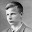

In [5]:
image = Image.open('../images/karatsuba032.jpg')
image

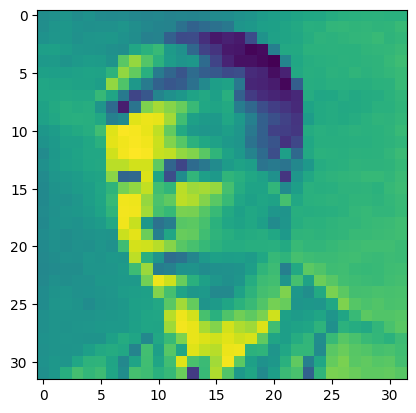

In [6]:
plt.imshow(image)

In [7]:
feature = np.array(image)
feature.shape

In [8]:
# Laplace discrete operator #
weight = np.array([
    [ 0, 1, 0],
    [ 1, -4, 1],
    [ 0, 1, 0],
])
weight

array([[ 0,  1,  0],
       [ 1, -4,  1],
       [ 0,  1,  0]])

Convolution with no paddin and stride 1
Using convolve2d from scipy, our gold method, it's necessary to reverse the weights to get same result of naive and fast convolution

In [9]:
wr = weight[::-1, ::-1]
wr

array([[ 0,  1,  0],
       [ 1, -4,  1],
       [ 0,  1,  0]])

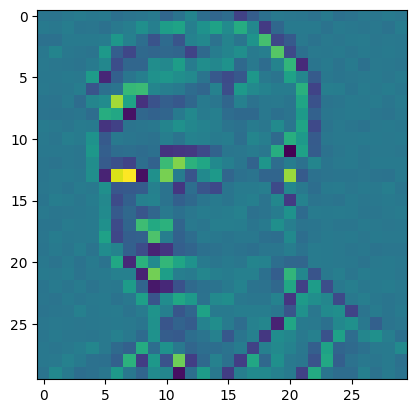

In [10]:
output = signal.convolve2d(feature, wr, mode='valid')
plt.imshow(output)

In [11]:
output[:5, :5]

array([[ -8, -10,  -2,  10,  -1],
       [  6,  -1,  16,  -8,  -7],
       [-19, -19,   5,   8,   7],
       [  0,  33,   0,  -6, -10],
       [  2,  -4,  -6, -10,   8]])

Running naive convolution
9 multiplications and 8 aditions per output scalar

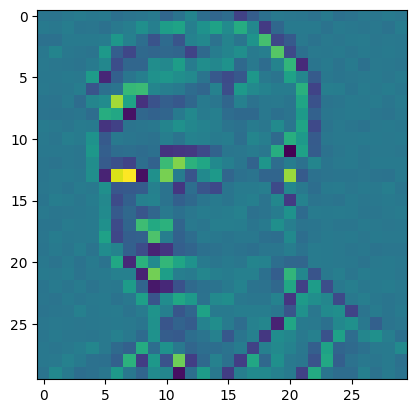

In [12]:
output_naive = naive_convolve(feature, weight)
plt.imshow(output_naive)

In [13]:
np.all(output == output_naive)

True

In [14]:
data_small = feature[:3, :3]
data_small

array([[118, 120, 124],
       [119, 125, 127],
       [122, 126, 127]], dtype=uint8)

In [15]:
output_small = signal.convolve2d(data_small, wr)
output_small

array([[   0,  118,  120,  124,    0],
       [ 118, -233, -113, -249,  124],
       [ 119, -111,   -8, -132,  127],
       [ 122, -243, -130, -255,  127],
       [   0,  122,  126,  127,    0]])

In [16]:
data_big = feature[:5, :5]
data_big

array([[118, 120, 124, 118, 122],
       [119, 125, 127, 122, 120],
       [122, 126, 127, 121, 125],
       [135, 136, 133, 126, 125],
       [129, 131, 124, 130, 133]], dtype=uint8)

In [17]:
points = [0, 1, -1, 2, np.inf]
points

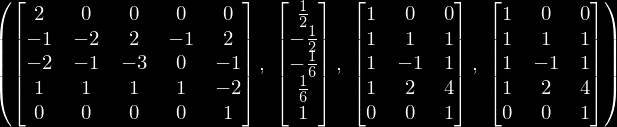

In [18]:
c1, cq1, b1, a1 = toom_cook(3, 3, points)
c1, cq1, b1, a1

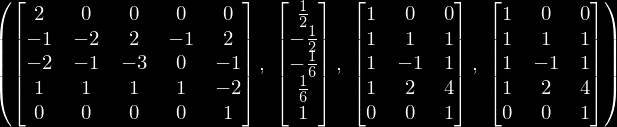

In [19]:
c2, cq2, b2, a2 = toom_cook(3, 3, points)
c2, cq2, b2, a2

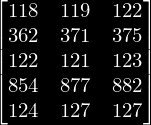

In [20]:
d1 = sy.Matrix([[a2*sy.Matrix(data_small[d]) for d in range(3)]])
d1

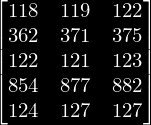

In [21]:
d1 = a2 * data_small.T
d1

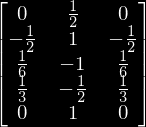

In [22]:
bg1 = sy.Matrix([[sy.diag(*cq2) * b2 * sy.Matrix(w) for w in weight]])
bg1

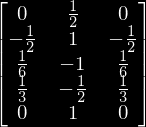

In [23]:
bg1 = sy.diag(*cq2) * b2 * sy.Matrix(weight.T)
bg1

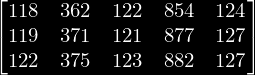

In [24]:
d1.T

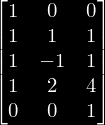

In [25]:
a1

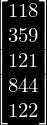

In [26]:
a1 * d1.T[::, 0]

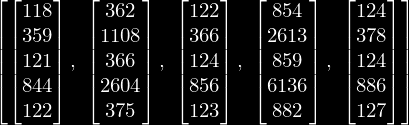

In [27]:
d2 = [a1 * d1.T[::, i] for i in range(5)]
# or #
# d2 = [a1 * sy.Matrix(d) for d in d1.tolist()] #
d2

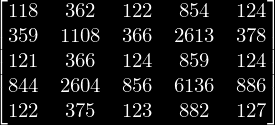

In [28]:
d2 = a1 * d1.T
d2

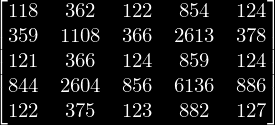

In [29]:
a1 * (a2 * data_small.T).T

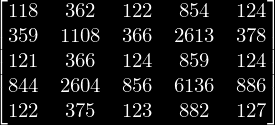

In [30]:
a1 * (a2 * data_small.T).T

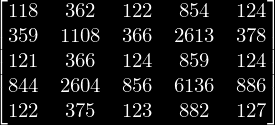

In [31]:
a1 * data_small * a2.T

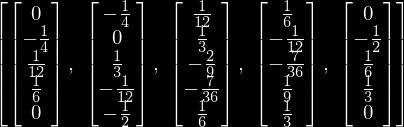

In [32]:
bg2 = [(sy.diag(*cq2) * b2) * bg1.T[::, i] for i in range(5)]
bg2

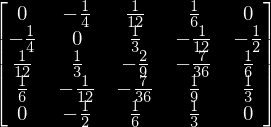

In [33]:
bg2 = (sy.diag(*cq2) * b2) * bg1.T
bg2

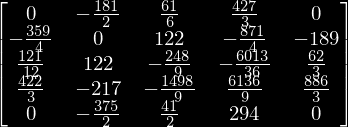

In [34]:
m = sy.HadamardProduct(d2, bg2, evaluate=True)
m

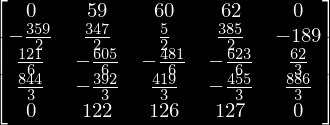

In [35]:
s1 = m * c1.T
s1

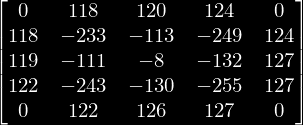

In [36]:
s2 = c2 * m * c1.T
s2

In [37]:
output_small

array([[   0,  118,  120,  124,    0],
       [ 118, -233, -113, -249,  124],
       [ 119, -111,   -8, -132,  127],
       [ 122, -243, -130, -255,  127],
       [   0,  122,  126,  127,    0]])

In [38]:
np.array(s2) == output_small

array([[ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True]])

In [39]:
# sy.MatMul(a0.T, bg0, c0.T, sy.Matrix(feature[0, :5])) #

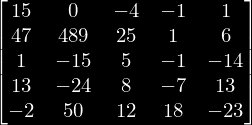

In [40]:
d2 = c1.T * data_big * c2
d2

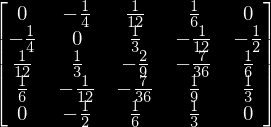

In [41]:
bg2 = (sy.diag(*cq2) * b2) * sy.Matrix(weight) * (sy.diag(*cq1) * b1).T
bg2

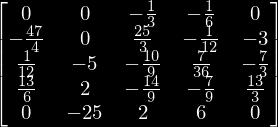

In [42]:
m = sy.HadamardProduct(d2, bg2, evaluate=True)
m

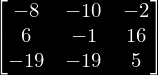

In [43]:
s = a1.T * m * a2
s

In [44]:
np.array(s) == output[:3, :3]

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True]])

Lets try with tensor product

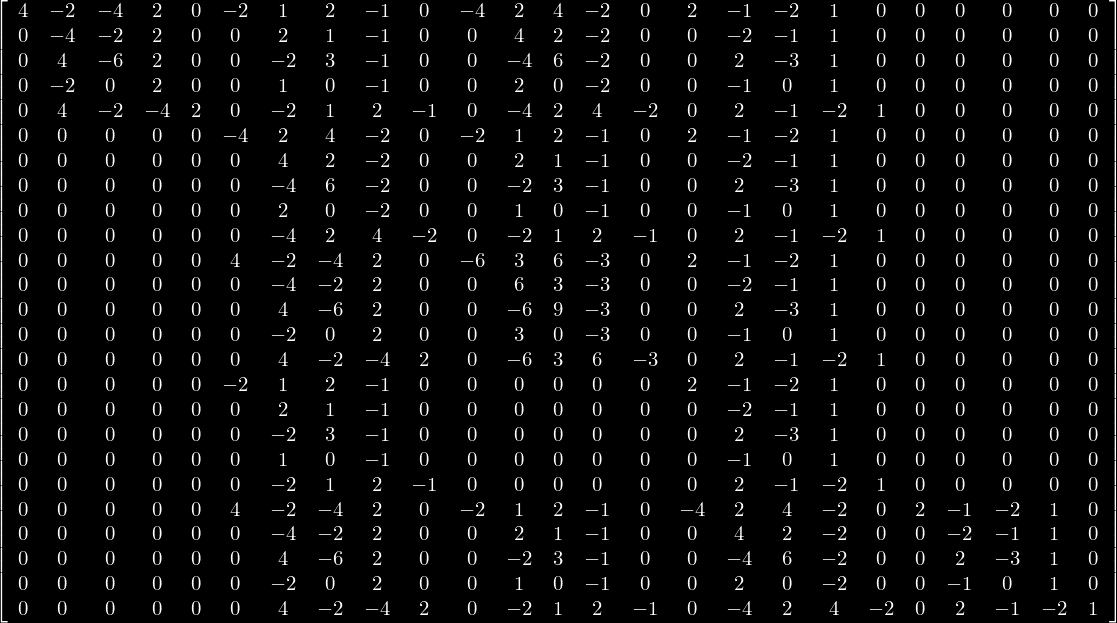

In [45]:
dt = TensorProduct(c1.T, c2.T)
# or #
# dt = TensorProduct(c1, c2).T #
dt

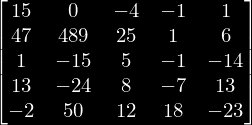

In [46]:
d2 = (dt * sy.Matrix(data_big.reshape(-1))).reshape(5, 5)
d2

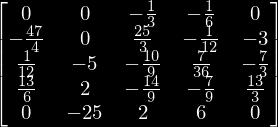

In [47]:
m = sy.HadamardProduct(d2, bg2, evaluate=True)
m

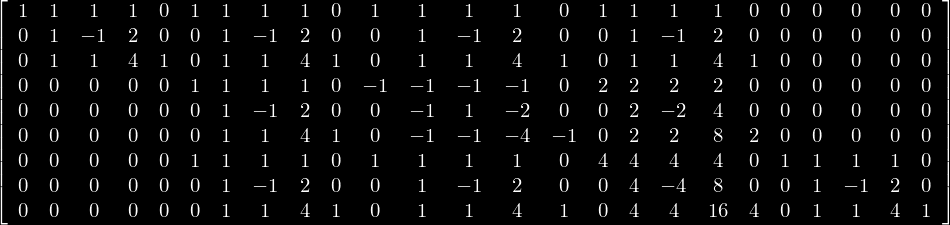

In [48]:
at = TensorProduct(a1, a2).T
at

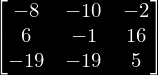

In [49]:
s = (at * sy.Matrix(np.array(m).reshape(-1))).reshape(3, 3)
s

Try 1.5D

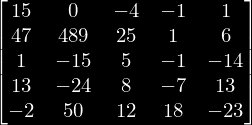

In [50]:
d2 = c1.T * data_big * c2
d2

basic quantization

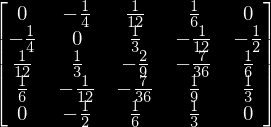

In [51]:
bg2 = (sy.diag(*cq2) * b2) * sy.Matrix(weight) * (sy.diag(*cq1) * b1).T
bg2

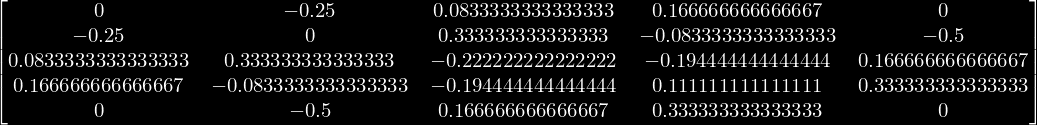

In [52]:
M(np.array(bg2, dtype=float))

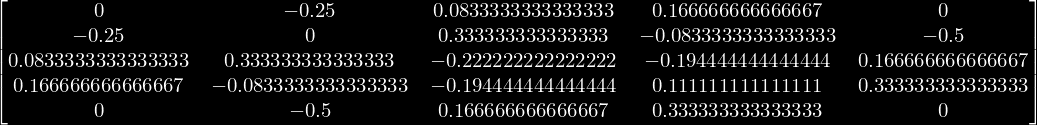

In [56]:
M(np.array(g_to_bg2d(cq1, b1, cq2, b2, weight), dtype=float))
